### 타이타닉 탑승자 데이터
| 컬럼명              | 설명                                                        |
| ---------------- | --------------------------------------------------------- |
| **survived**     | 생존 여부 (0 = 사망, 1 = 생존)                                    |
| **pclass**       | 선실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)                         |
| **sex**          | 성별 ('male', 'female')                                     |
| **age**          | 나이                                                        |
| **sibsp**        | 함께 탑승한 형제/배우자 수 (siblings/spouses)                        |
| **parch**        | 함께 탑승한 부모/자녀 수 (parents/children)                         |
| **fare**         | 승객 요금                                                     |
| **embarked**     | 탑승 항구 코드 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| **class**        | `pclass`와 동일하지만 문자열로 표시 ('First', 'Second', 'Third')      |
| **who**          | 승객 구분 ('man', 'woman', 'child')                           |
| **adult\_male**  | 성인 남성 여부 (True/False)                                     |
| **deck**         | 객실이 위치한 갑판 (A\~G 등, 일부 결측값 존재)                            |
| **embark\_town** | 탑승 도시명 (예: 'Cherbourg', 'Southampton')                    |
| **alive**        | 생존 여부 문자열 ('yes' 또는 'no')                                 |
| **alone**        | 혼자 탑승 여부 (True/False)                                     |

※ survived와 alive은 같은 컬럼이므로 alive제외하고 훈련해야함


In [321]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,  classification_report

In [322]:
import platform
import sklearn

if platform.system() == 'Windows':
    sklearn.set_config(display='text')


In [323]:
titanic = sns.load_dataset('titanic')
print(titanic.columns)
print(titanic.info())
print(titanic.head(2))

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        

In [324]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [325]:
titanic.isnull().sum(axis=0)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [326]:
# titanic['age'].fillna(titanic['age'].mean(), inplace=True)

# pandas 3.0 부터 변경됨
titanic.fillna({'age': titanic['age'].mean()}, inplace=True)

In [327]:
titanic['age'].isnull().sum()

np.int64(0)

In [328]:
titanic['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [329]:
titanic.fillna({'embarked':'N'}, inplace=True)

In [330]:
titanic['embarked'].isnull().sum()

np.int64(0)

In [331]:
# dtypedl category 이면 categories에 값을 먼저 등록해야 한다.
titanic['deck'] = titanic['deck'].cat.add_categories('N')
titanic.fillna({'deck':'N'}, inplace=True)
titanic['deck'].isnull().sum()

np.int64(0)

In [332]:
titanic['deck'].value_counts()      # N 688 로 추가되어서 나온다

deck
N    688
C     59
B     47
D     33
E     32
A     15
F     13
G      4
Name: count, dtype: int64

In [333]:
pd.__version__

'2.3.3'

In [334]:
titanic.fillna({'embark_town': 'N'}, inplace=True)
titanic['embark_town'].isnull().sum()

np.int64(0)

In [335]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [336]:
# 남, 여 탑승 수
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [337]:
print(dir(titanic))

['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__dataframe_consortium_standard__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', 

In [338]:
# 생존율 0(사망): 549, 1(생존): 342
titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [339]:
# 성별 생존여부
titanic.groupby(['sex'])['survived'].value_counts()
# titanic.groupby(['sex', 'survived']).count()

sex     survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='survived'>

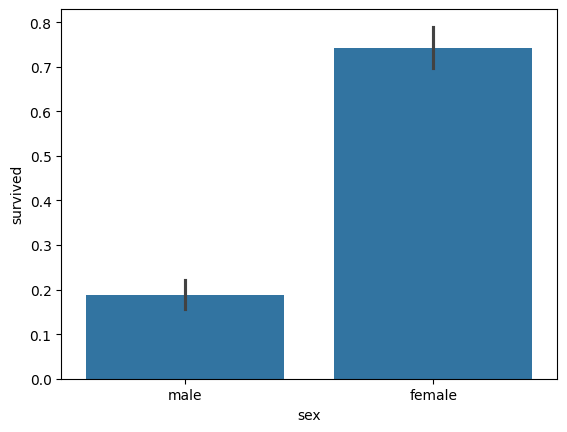

In [340]:
sns.barplot(data=titanic, x='sex', y='survived')

객실 등급별 성별에 따른 생존 확률
- 여성의 경우 일등실, 이등실에 따른 생존 확률의 차이는 크지 않으나, 삼등실의 경우 생존 확률이 상대적으로 많이 떨어짐을 알 수 있다.
- 남성의 경우는 일등실의 생존 확률이 이, 삼등실의 생존 확률보다 월등이 높다.
- 제임스 카메론의 영화인 '타이타닉'에서도 나왔듯이 바다에서 사고가 날 경우 여성과 아이들, 그리고 노약자가 제일 먼저 구조대상이다. 그리고 부자나 유명인이 다음 구조 대상이다. 삼등실에 탄 많은 가난한 이는 타이타닉 호와 운명을 함께 했다.

<Axes: xlabel='pclass', ylabel='survived'>

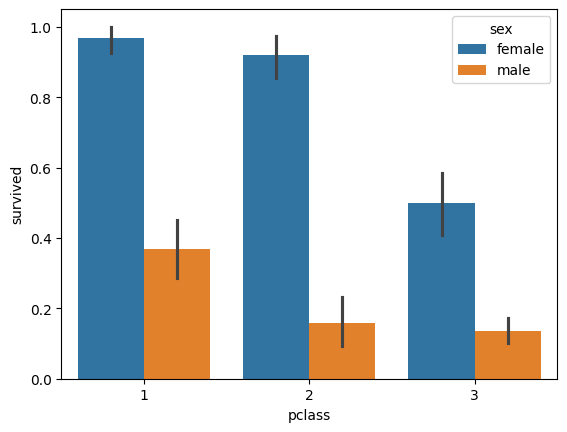

In [341]:
# 선실등급별 남녀 생존
sns.barplot(data=titanic, x='pclass', y='survived', hue='sex')

In [342]:
X_train, X_test, y_train, y_test = train_test_split(titanic.loc[:, 'pclass':'alone'], titanic['survived'], random_state=11)

In [343]:
model = LogisticRegression(max_iter=1000)

# 인코딩 전이라 문자열/카테고리 컬럼이 그대로 남아 있어서 학습이 실패한다.
# -> ValueError: could not convert string to float: 'male'
# 아래에서 LabelEncoder / OneHotEncoder 로 인코딩하는 이유가 바로 이것.
try:
    model.fit(X_train, y_train)
except ValueError as e:
    print('학습 실패:', e)

학습 실패: could not convert string to float: 'male'


In [344]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  891 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [345]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

### LabelEncoder() 로 인코딩

In [346]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic_df1 = titanic.copy()

# 변환할 컬럼 목록 (str, category)
label_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

for col in label_cols:
    titanic_df1[col] = le.fit_transform(titanic_df1[col])

In [347]:
titanic_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    int64  
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     891 non-null    int64  
 8   class        891 non-null    int64  
 9   who          891 non-null    int64  
 10  adult_male   891 non-null    bool   
 11  deck         891 non-null    int64  
 12  embark_town  891 non-null    int64  
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(10), object(1)
memory usage: 92.4+ KB


In [348]:
titanic_df1[label_cols].head()

,sex,embarked,class,who,deck,embark_town
0,1,3,2,1,7,3
1,0,0,0,2,2,0
2,0,3,2,2,7,3
3,0,3,0,2,2,3
4,1,3,2,1,7,3


In [349]:
print(titanic['sex'].head())
print()
print(titanic_df1['sex'].head())

0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: object

0    1
1    0
2    0
3    0
4    1
Name: sex, dtype: int64


In [350]:
titanic_df1['sex'].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [351]:
titanic_df1['deck'].value_counts()

deck
7    688
2     59
1     47
3     33
4     32
0     15
5     13
6      4
Name: count, dtype: int64

### OneHotEncoder(sparse_output=False, handle_unknown='ignore')

남 1 0 

여 0 1 

0 0 1 0 0 0 0 

0 0 0 0 0 1 0  => 데크 데이터 표현 7개의 셋이 만들어짐 -> 공간 낭비 심함 (희소행렬)

OneHotEncoder(sparse_output=False, handle_unknown='ignore')

| 파라미터                      | 설명                                                                            |
| ------------------------- | ----------------------------------------------------------------------------- |
| `sparse_output=False`     | 반환값을 **희소 행렬(sparse matrix)** 대신 **NumPy 배열**로 반환. <br> → DataFrame으로 변환하기 쉬움 |
| `handle_unknown='ignore'` | 학습 시 보지 못한 **새로운 범주가 등장해도 에러 없이 무시**. <br> → 안정적인 예측 및 인코딩 수행                 |


In [352]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd 
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

titanic_df2 = titanic.copy()

# 변환할 컬럼 목록
ohe_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town']

ohe_result = pd.DataFrame(index = titanic_df2.index)
print('ohe_result:', ohe_result.head())
print('ohe_result_len:', len(ohe_result))

for col in ohe_cols:
    encoded = ohe.fit_transform(titanic_df2[[col]])
    # print(encoded)

    col_names = ohe.get_feature_names_out([col])        # 무슨 인덱스인지 구분이 안 가니 확인
    # print(col_names)        # ['sex_female' 'sex_male']

    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df2.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)
    # print(ohe_result.head())
    # break

ohe_result: Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
ohe_result_len: 891


In [353]:
ohe_result.head()

,sex_female,sex_male,embarked_C,embarked_N,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [354]:
# survived 와 alive 컬럼 2개가 생존여부 의미 -> alive 컬럼 삭제
titanic_df2.drop(columns=['alive'], inplace=True)

In [355]:
titanic_df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,N,Southampton,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,N,Southampton,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,N,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,N,Southampton,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,N,Southampton,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,True


In [356]:
# 원본 범주형 컬럼 삭제 (인코딩 결과 ohe_result 로 대체)
titanic_df2.drop(columns=ohe_cols, inplace=True)

In [357]:
titanic_df2 = pd.concat([titanic_df2, ohe_result], axis=1)

In [358]:
print(titanic_df2.columns)
titanic_df2.head(1)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_N',
       'embarked_Q', 'embarked_S', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton'],
      dtype='object')


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,...,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Cherbourg,embark_town_N,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.25,True,False,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


| 컬럼명           | 타입       | 인코딩 방식        | 설명                      |
| ------------- | -------- | ------------- | ----------------------- |
| `sex`         | str   | OneHotEncoder | 남/여 → 순서 의미 없음          |
| `embarked`    | str   | OneHotEncoder | 탑승 항구 (순서 없음)           |
| `class`       | category | LabelEncoder  | 1등, 2등, 3등 (순서 있음)      |
| `who`         | str   | OneHotEncoder | man/woman/child (순서 없음) |
| `deck`        | category | OneHotEncoder | 갑판 A\~G,N (순서 없음)       |
| `embark_town` | str   | OneHotEncoder | 도시명 (순서 없음)             |
| `alive`       | str   | LabelEncoder  | yes/no → 이진             |
| `adult_male`  | bool     | LabelEncoder  | True/False → 1/0        |
| `alone`       | bool     | LabelEncoder  | True/False → 1/0        |


In [359]:
titanic_df3 = titanic.copy()

# 1. LabelEncoder 적용할 컬럼
label_cols = ['class', 'adult_male', 'alone']
le = LabelEncoder()

for col in label_cols:
    titanic_df3[col] = le.fit_transform(titanic_df3[col])

# 2. OneHotEncoder 적용할 컬럼
ohe_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 결과를 저장할 DataFrame
ohe_result = pd.DataFrame(index=titanic_df3.index)

for col in ohe_cols:
    #encoded 타입은 ndarray
    encoded = ohe.fit_transform(titanic_df3[[col]])
    col_names = ohe.get_feature_names_out([col])
    encoded_df = pd.DataFrame(encoded, columns=col_names, index=titanic_df3.index)
    ohe_result = pd.concat([ohe_result, encoded_df], axis=1)

# 기존 원본 컬럼 삭제 후 병합
titanic_df3 = pd.concat([titanic_df3.drop(columns=ohe_cols), ohe_result], axis=1)
print(titanic_df3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   survived                 891 non-null    int64  
 1   pclass                   891 non-null    int64  
 2   age                      891 non-null    float64
 3   sibsp                    891 non-null    int64  
 4   parch                    891 non-null    int64  
 5   fare                     891 non-null    float64
 6   class                    891 non-null    int64  
 7   adult_male               891 non-null    int64  
 8   alive                    891 non-null    object 
 9   alone                    891 non-null    int64  
 10  sex_female               891 non-null    float64
 11  sex_male                 891 non-null    float64
 12  embarked_C               891 non-null    float64
 13  embarked_N               891 non-null    float64
 14  embarked_Q               8

In [360]:
titanic_df3.drop(columns=['alive'], inplace=True)

In [361]:
titanic_df3.columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'class',
       'adult_male', 'alone', 'sex_female', 'sex_male', 'embarked_C',
       'embarked_N', 'embarked_Q', 'embarked_S', 'who_child', 'who_man',
       'who_woman', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F',
       'deck_G', 'deck_N', 'embark_town_Cherbourg', 'embark_town_N',
       'embark_town_Queenstown', 'embark_town_Southampton'],
      dtype='object')

데이터 전처리를 단계별로 진행할 때 범주형 변수와 연속형 변수를 나누고, 개별적으로 전처리하는 과정을 했다.
sklean-learn에서 제공하는 make_column_transformer와 ColumnTransformer을 이용해서 범주형변수와 연속형 변수를 한번에  전처리를 할 수 있도록 제공해준다.

make_column_transformer를 이용한 인코딩
- make_column_transformer((전처리 객체, 전처리를 적용할 컬럼), (전처리 객체, 전처리를 적용할 컬럼))
- LabelEncoder는 1차원만 처리 가능하므로 make_column_transformer에 직접 쓸 수 없습니다. 대신 **OrdinalEncoder**를 사용한다.

### make_column_transformer

In [362]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

titanic_df4 = titanic.copy()

In [363]:
titanic_df4.drop(columns=['alive'], inplace=True)

In [364]:
titanic_df4.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alone'],
      dtype='object')

In [365]:
#인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols =  ['class', 'adult_male', 'alone']

# make_column_transformer
    #remainder='passthrough' : 나머지 컬럼은 그대로 유지 (예: age, fare 등)
column_transformer = make_column_transformer((OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
                                            (OrdinalEncoder(),ordinal_cols),
                                            remainder='passthrough')

# 변환 적용
encoded = column_transformer.fit_transform(titanic_df4)

In [366]:
# encoded
# titanic_df4

# 컬럼 이름 추출
print(column_transformer.named_transformers_)

onehot_feature_names = column_transformer.named_transformers_['onehotencoder'].get_feature_names_out(onehot_cols)
print(f'onehot_feature_names:{onehot_feature_names}')

ordinal_feature_names = ordinal_cols
print(f'ordinal_feature_names:{ordinal_feature_names}')

other_feature_name = [col for col in titanic_df4.columns if col not in onehot_cols + ordinal_cols]
print(f'other_feature_name: {other_feature_name}')

print(type(other_feature_name))     # list
print(type(onehot_feature_names))       # np.ndarray (1차원)
print(type(ordinal_feature_names))      # list

# 주의! 이름 순서는 encoded 의 컬럼 순서와 똑같아야 한다.
# ColumnTransformer 의 출력 순서 = 등록한 transformer 순서 + remainder(passthrough) 가 마지막
# 즉 onehot -> ordinal -> 나머지 순서다. (other 를 앞에 두면 값과 이름이 어긋난다)
final_feature_names = list(onehot_feature_names) + ordinal_feature_names + other_feature_name
print(f'final_feature_names: {final_feature_names}')


# DataFrame으로 변환
titanic_df4 = pd.DataFrame(encoded, columns = final_feature_names, index=titanic_df4.index)
print(titanic_df4.head())

{'onehotencoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False), 'ordinalencoder': OrdinalEncoder(), 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                    feature_names_out='one-to-one')}
onehot_feature_names:['sex_female' 'sex_male' 'embarked_C' 'embarked_N' 'embarked_Q'
 'embarked_S' 'who_child' 'who_man' 'who_woman' 'deck_A' 'deck_B' 'deck_C'
 'deck_D' 'deck_E' 'deck_F' 'deck_G' 'deck_N' 'embark_town_Cherbourg'
 'embark_town_N' 'embark_town_Queenstown' 'embark_town_Southampton']
ordinal_feature_names:['class', 'adult_male', 'alone']
other_feature_name: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
<class 'list'>
<class 'numpy.ndarray'>
<class 'list'>
final_feature_names: ['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N', 'embark_town_Cherbourg', 'embark_town_N', 'embark_tow

In [367]:
feature_names = column_transformer.get_feature_names_out()
# print(feature_names)
encoded_df_default = pd.DataFrame(encoded, columns=feature_names)
print(encoded_df_default)

     onehotencoder__sex_female  onehotencoder__sex_male  \
0                          0.0                      1.0   
1                          1.0                      0.0   
2                          1.0                      0.0   
3                          1.0                      0.0   
4                          0.0                      1.0   
..                         ...                      ...   
886                        0.0                      1.0   
887                        1.0                      0.0   
888                        1.0                      0.0   
889                        0.0                      1.0   
890                        0.0                      1.0   

     onehotencoder__embarked_C  onehotencoder__embarked_N  \
0                          0.0                        0.0   
1                          1.0                        0.0   
2                          0.0                        0.0   
3                          0.0                 

In [368]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

titanic_df4 = titanic.copy()
# encoded 는 alive 를 뺀 상태로 fit_transform 한 결과이므로 여기서도 똑같이 alive 를 빼야
# 컬럼 개수(30개)가 맞는다. 안 빼면 ValueError: Shape of passed values is (891, 30), indices imply (891, 31)
titanic_df4.drop(columns=['alive'], inplace=True)

In [369]:
# encoded 
# titanic_df4

# 컬럼 이름 추출
print(column_transformer.named_transformers_)


onehot_feature_names = column_transformer.named_transformers_['onehotencoder'].get_feature_names_out(onehot_cols)
print(f'onehot_feature_names: {onehot_feature_names}')

ordinal_feature_names = ordinal_cols
print(f'ordinal_feature_names : {ordinal_feature_names}')

other_feature_name = [col for col in titanic_df4.columns if col not in onehot_cols + ordinal_cols]
print(f'other_feature_name: {other_feature_name}')

print(type(other_feature_name))   # <class 'list'>
print(type(onehot_feature_names))  # <class 'numpy.ndarray'>
print(type(ordinal_feature_names))  # <class 'list'>

# 출력 순서: onehot -> ordinal -> remainder(passthrough)
final_feature_names = list(onehot_feature_names) + ordinal_feature_names + other_feature_name
print(f'final_feature_names:{final_feature_names}')

# DataFrame으로 변환
titanic_df4 = pd.DataFrame(encoded, columns = final_feature_names , index=titanic_df4.index)
print(titanic_df4.head())

{'onehotencoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False), 'ordinalencoder': OrdinalEncoder(), 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                    feature_names_out='one-to-one')}
onehot_feature_names: ['sex_female' 'sex_male' 'embarked_C' 'embarked_N' 'embarked_Q'
 'embarked_S' 'who_child' 'who_man' 'who_woman' 'deck_A' 'deck_B' 'deck_C'
 'deck_D' 'deck_E' 'deck_F' 'deck_G' 'deck_N' 'embark_town_Cherbourg'
 'embark_town_N' 'embark_town_Queenstown' 'embark_town_Southampton']
ordinal_feature_names : ['class', 'adult_male', 'alone']
other_feature_name: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
<class 'list'>
<class 'numpy.ndarray'>
<class 'list'>
final_feature_names:['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q', 'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N', 'embark_town_Cherbourg', 'embark_town_N', 'embark_t

In [370]:
titanic_df5 = titanic.copy()
titanic_df5.drop(columns=['alive'], inplace=True)   # survived 와 중복(정답 누수) 이므로 제외

column_transformer_ignore = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
    (OrdinalEncoder(), ordinal_cols),
    remainder='passthrough',
    verbose_feature_names_out=False  # 접두사 제거 옵션
)

encoded5 = column_transformer_ignore.fit_transform(titanic_df5)
feature_names = column_transformer_ignore.get_feature_names_out()

encoded_df = pd.DataFrame(encoded5, columns=feature_names, index=titanic_df5.index)
print(f'encoded_df :{encoded_df.columns}')
print(encoded_df)

encoded_df :Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'survived',
       'pclass', 'age', 'sibsp', 'parch', 'fare'],
      dtype='object')
     sex_female  sex_male  embarked_C  embarked_N  embarked_Q  embarked_S  \
0           0.0       1.0         0.0         0.0         0.0         1.0   
1           1.0       0.0         1.0         0.0         0.0         0.0   
2           1.0       0.0         0.0         0.0         0.0         1.0   
3           1.0       0.0         0.0         0.0         0.0         1.0   
4           0.0       1.0         0.0         0.0         0.0         1.0   
..          ...       ...         ...         ...         ...         ...   
886

ColumnTransformer는 이용한 인코딩
- make_column_transformer와 별칭 지정 유무만 차이가 있고 결과는 동일하게 나온다.
- ColumnTransformer(transformers=[(별칭, 전처리 객체, 전처리를 적용할 컬럼),(별칭, 전처리 객체, 전처리를 적용할 컬럼)],remainder='passthrough')

In [371]:
from sklearn.compose import ColumnTransformer

titanic_df5 = titanic.copy()
titanic_df5.drop(columns=['alive'], inplace=True)

In [372]:
# 1. 정답(target) 과 입력(feature) 분리
#    DataFrame 은 df[행, 열] 형태의 2차원 인덱싱을 지원하지 않는다.
#    df[:, 1:]  -> InvalidIndexError  (튜플을 '컬럼명'으로 찾으려다 실패)
#    위치로 자르려면 .iloc[:, 1:], 이름으로 빼려면 drop(columns=...) 를 쓴다.
target = titanic_df5['survived']
features = titanic_df5.drop(columns=['survived'])   # == titanic_df5.iloc[:, 1:]
print('target:', target.shape, '/ features:', features.shape)

# 2. 인코더 지정
onehot_cols = ['sex', 'embarked', 'who', 'deck', 'embark_town']
ordinal_cols = ['class',  'adult_male', 'alone']

# 3. ColumnTransformer 정의
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_cols),
        ('ordinal', OrdinalEncoder(), ordinal_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False  # 컬럼명에 'onehot__', 'ordinal__' 접두사 제거
)

# 4. 변환 실행 (정답을 뺀 features 로 변환해야 한다)
encoded_array = ct.fit_transform(features)

# 5. 변환된 컬럼명 추출 및 DataFrame 생성
feature_names = ct.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_array, columns=feature_names, index=features.index)
print(encoded_df.head())

target: (891,) / features: (891, 13)
   sex_female  sex_male  embarked_C  embarked_N  embarked_Q  embarked_S  \
0         0.0       1.0         0.0         0.0         0.0         1.0   
1         1.0       0.0         1.0         0.0         0.0         0.0   
2         1.0       0.0         0.0         0.0         0.0         1.0   
3         1.0       0.0         0.0         0.0         0.0         1.0   
4         0.0       1.0         0.0         0.0         0.0         1.0   

   who_child  who_man  who_woman  deck_A  ...  embark_town_Queenstown  \
0        0.0      1.0        0.0     0.0  ...                     0.0   
1        0.0      0.0        1.0     0.0  ...                     0.0   
2        0.0      0.0        1.0     0.0  ...                     0.0   
3        0.0      0.0        1.0     0.0  ...                     0.0   
4        0.0      1.0        0.0     0.0  ...                     0.0   

   embark_town_Southampton  class  adult_male  alone  pclass   age  sibsp

In [373]:
print(encoded_df.columns)

Index(['sex_female', 'sex_male', 'embarked_C', 'embarked_N', 'embarked_Q',
       'embarked_S', 'who_child', 'who_man', 'who_woman', 'deck_A', 'deck_B',
       'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_N',
       'embark_town_Cherbourg', 'embark_town_N', 'embark_town_Queenstown',
       'embark_town_Southampton', 'class', 'adult_male', 'alone', 'pclass',
       'age', 'sibsp', 'parch', 'fare'],
      dtype='object')


In [375]:
pd.concat([target, encoded_df], axis=1)
titanic_df5.head(1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,N,Southampton,False


In [385]:
X_train, X_test, y_train, y_test = train_test_split(encoded_df, target, test_size=0.25)
print(f'X_train: ', X_train.shape)
print(f'X_train: ', X_test.shape)
print(f'X_train: ', y_train.shape)
print(f'X_train: ', y_test.shape)

X_train:  (668, 29)
X_train:  (223, 29)
X_train:  (668,)
X_train:  (223,)


In [389]:
# LogisticRegression 알고리즘
model = LogisticRegression(max_iter=1000)

# 훈련
model.fit(X_train, y_train)

# 테스트
y_pred = model.predict(X_test)

In [ ]:
# 
confusion_matrix(y_test, y_pred)

In [390]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       137
           1       0.81      0.78      0.79        86

    accuracy                           0.84       223
   macro avg       0.84      0.83      0.83       223
weighted avg       0.84      0.84      0.84       223

